# **Reporte de laboratorio 4 - Señales ECG**

# **1. Introducción**


# **2. Objetivos**


# **3. Materiales**


# **4. Procedimiento**
Para el sensado de las señales EMG se basa mediante la bibliografía proporcionada en el laboratorio y se seleccionan tres ejercicios en donde un músculo designado es el evaluado. 
Los movimientos a considerar son los siguientes:
- Músculo ***en reposo***
- Músculo ***en movimiento voluntario***
- Músculo ***en movimiento voluntario con carga opuesta***

## **Conexión de electrodos**


## **4.1. Prueba 1: Reposo**


## **4.2. Prueba 2: Contención de aire (30 seg) y descanso (1 min)**


## **4.3. Prueba 3: Actividad física aeróbica**


#### *Nota: los videos referentes a cada uno de los procedimientos se encuentran en la carpeta Videos*

# **5. Resultados**
 <p align="justify">
 En el procesamiento de señales ECG, es común aplicar un filtro pasa-banda previo al análisis para mejorar la calidad de la señal y facilitar la detección de las ondas características. Esto se debe a que la actividad eléctrica del corazón se concentra principalmente en un rango de frecuencias bien definido, mientras que otros componentes fuera de este rango suelen corresponder a ruido o artefactos.

De acuerdo con Zyout et al., antes del análisis el ECG “is typically band-pass filtered using several frequency ranges. The frequency range used is 0.5 – 40 Hz” [1]. Este rango permite eliminar el ruido de baja frecuencia asociado a movimientos respiratorios o a la deriva de la línea base (< 0.5 Hz), al mismo tiempo que atenúa componentes de alta frecuencia (> 40 Hz) causados por la actividad muscular o interferencias eléctricas, conservando únicamente la información clínica relevante (ondas P, complejo QRS y onda T).
</p>

## **5.1. Prueba 1: Reposo**


## **5.2. Prueba 2: Contención de aire (30 seg) y descanso (1 min)**


## **5.3. Prueba 3: Actividad física aeróbica**


## **5.4 Interpretación de resultados**


# **6. Referencias**
-  Zyout, A. A., Alquran, H., Mustafa, W. A., & Alqudah, A. M. (2023). Advanced time-frequency methods for ecg waves recognition. Diagnostics, 13(2), 308.

# **7. Anexo**

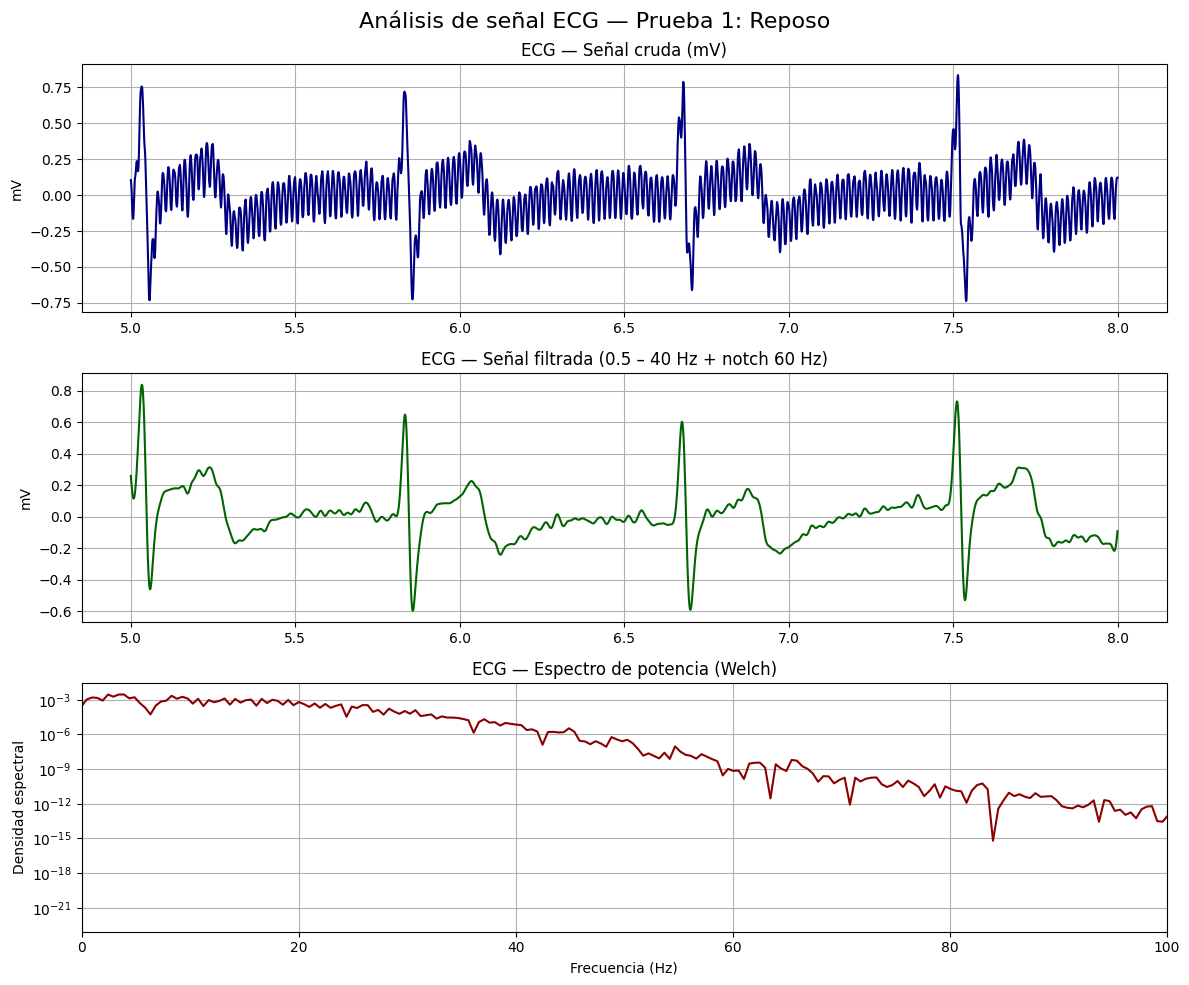

In [14]:
# Ejemplo de código para análisis de señal ECG: 
# Filtros y espectro de potencia
# Resultados para la Prueba 1: Reposo

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch

# Parámetros del BITalino
Fs = 1000         # Hz
VCC = 3.3         # V referencia ADC
ADCres = 1023     # 10 bits
GAIN_ECG = 1100   # ganancia típica ECG (ajústala si tu módulo difiere)

# Carga y conversión ADC -> mV
ecg_adc = np.loadtxt("Señales bitalino/ecg_reposo_inicial.txt", usecols=[-1])
ecg_V  = ((ecg_adc / ADCres) - 0.5) * VCC / GAIN_ECG
ecg_mV = ecg_V * 1000

# Intervalo de muestra de interés: 5 - 8 s
i0, i1 = int(5*Fs), int(8*Fs)
x  = ecg_mV[i0:i1]
t  = np.arange(i0, i1) / Fs

# Filtros: pasa-banda (0.5 – 40 Hz) + notch 60 Hz
b_bp, a_bp = butter(4, [0.5/(Fs/2), 40/(Fs/2)], btype="band")
x_bp = filtfilt(b_bp, a_bp, x)

b_n, a_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x_filt = filtfilt(b_n, a_n, x_bp)

# Espectro de potencia (Welch)
nper = min(2048, len(x_filt))
f, Pxx = welch(x_filt - np.mean(x_filt), fs=Fs, nperseg=nper)

# Gráficas
plt.figure(figsize=(12, 10))
plt.suptitle("Análisis de señal ECG — Prueba 1: Reposo", fontsize=16)

# 1) Señal cruda
plt.subplot(3,1,1)
plt.plot(t, x, color="navy")
plt.title("ECG — Señal cruda (mV)")
plt.ylabel("mV"); plt.grid(True)

# 2) Señal con filtros (pasa-banda 0.5 – 40 Hz + notch 60 Hz)
plt.subplot(3,1,2)
plt.plot(t, x_filt, color="darkgreen")
plt.title("ECG — Señal filtrada (0.5 – 40 Hz + notch 60 Hz)")
plt.ylabel("mV"); plt.grid(True)

# 3) Espectro de potencia (Welch)
plt.subplot(3,1,3)
plt.semilogy(f, Pxx, color="darkred")
plt.title("ECG — Espectro de potencia (Welch)")
plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Densidad espectral"); plt.grid(True)
plt.xlim(0, 100)  # ECG relevante < 40 Hz

plt.tight_layout()
plt.show()